# Problem 1 Question 2.1 - CNN

Mounted at /content/drive
Models will be saved to: /content/drive/MyDrive/models


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


dataset_infos.json:   0%|          | 0.00/943 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/88.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/27000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 27000
    })
})
Image shape: (27000, 64, 64, 3)
Label shape: (27000,)
Dataset shapes:
Train images: (17280, 64, 64, 3)
Train labels: (17280,)
Validation images: (4320, 64, 64, 3)
Validation labels: (4320,)
Test images: (5400, 64, 64, 3)
Test labels: (5400,)


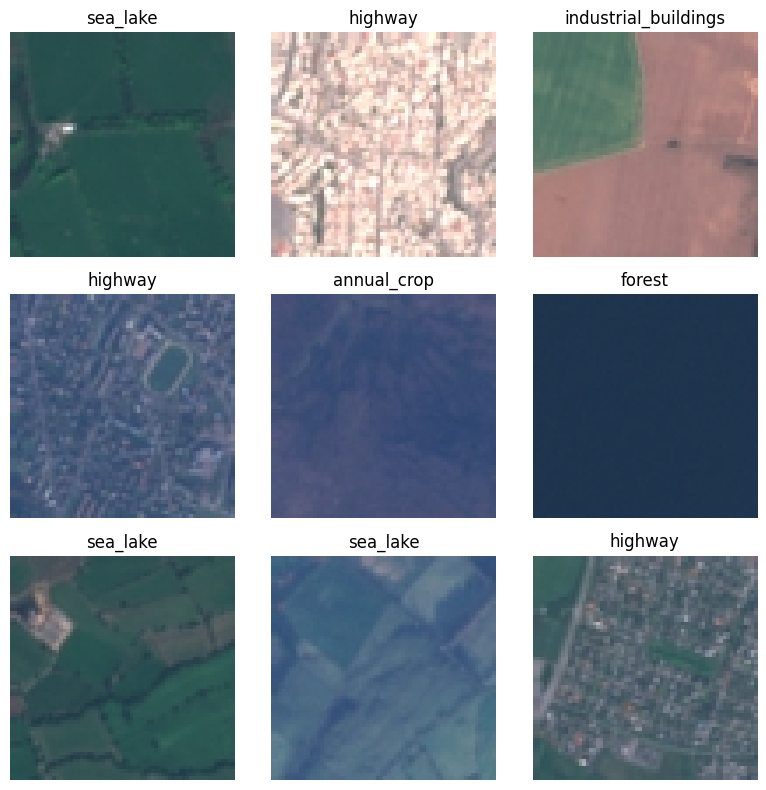

Data shapes (preprocessing will happen in model):
Train: (17280, 64, 64, 3)
Validation: (4320, 64, 64, 3)
Test: (5400, 64, 64, 3)

BUILDING BASELINE EFFICIENTNETB0 MODEL
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Base model loaded - all layers frozen


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_vector (Dense)          │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,829 (16.08 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 4,049,571 (15.45 MB)


Training baseline model...
Epoch 1/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6001 - loss: 1.3253
Epoch 1: val_loss improved from inf to 0.33316, saving model to /content/drive/MyDrive/models/EFFICIENTNETB0_baseline.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 32s 35ms/step - accuracy: 0.6004 - loss: 1.3245 - val_accuracy: 0.9053 - val_loss: 0.3332
Epoch 2/50
538/540 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8823 - loss: 0.3963
Epoch 2: val_loss improved from 0.33316 to 0.23368, saving model to /content/drive/MyDrive/models/EFFICIENTNETB0_baseline.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.8823 - loss: 0.3961 - val_accuracy: 0.9278 - val_loss: 0.2337
Epoch 3/50
538/540 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9006 - loss: 0.2989
Epoch 3: val_loss improved from 0.23368 to 0.20062, saving model to /content/drive/MyDrive/models/EFFICIENTNETB0_baseline.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.9006 - loss: 0.2989 - val_accuracy: 

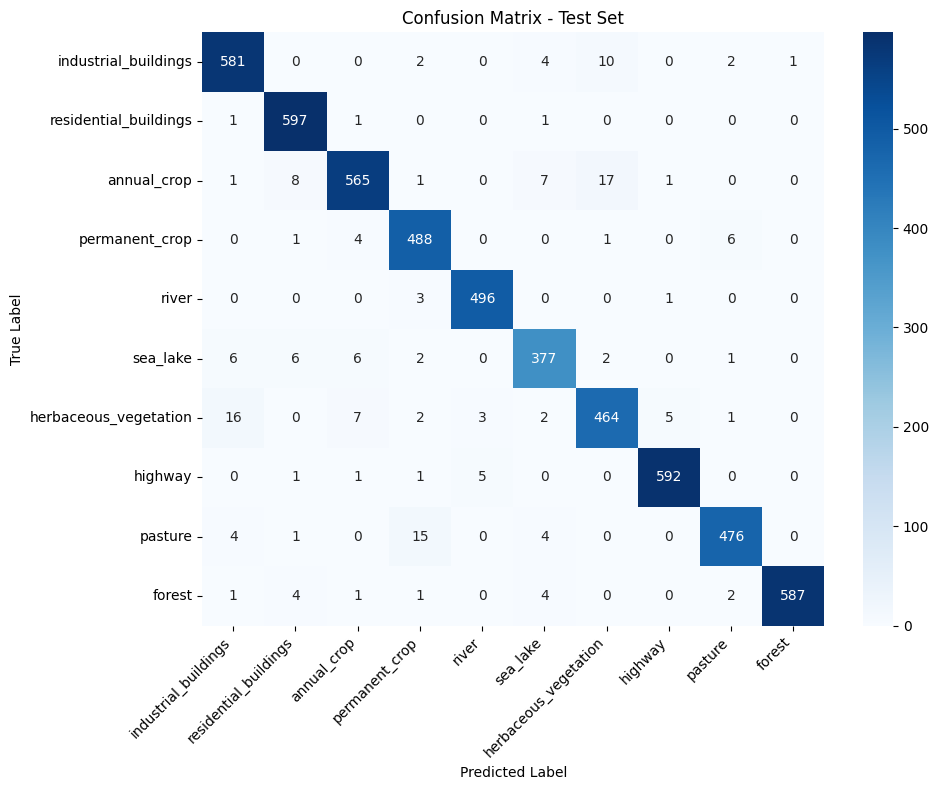


PLOTTING TRAINING HISTORY


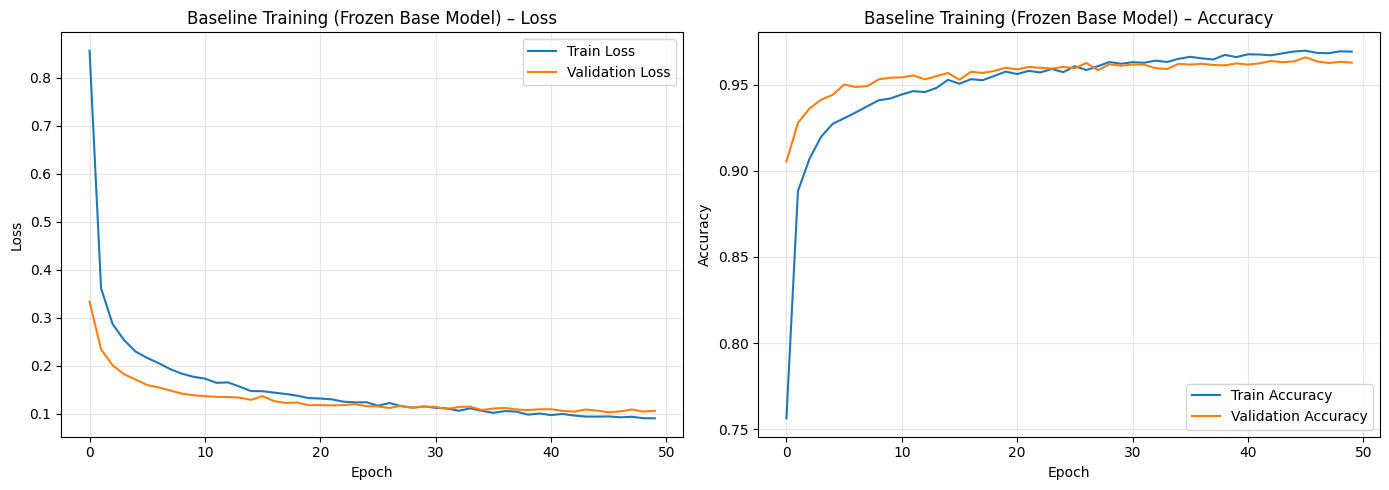

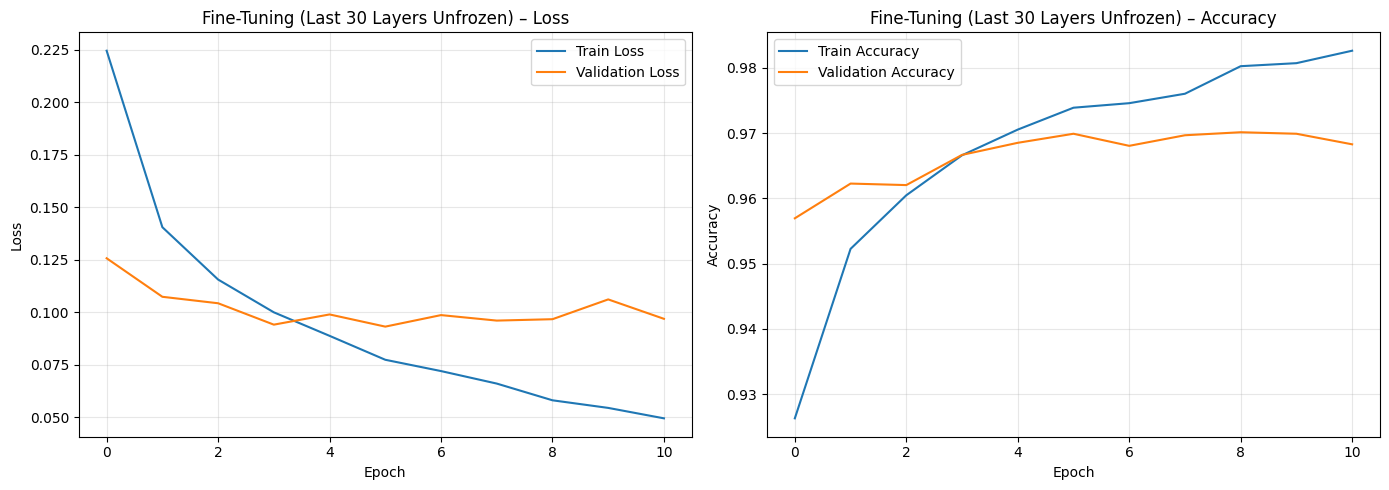

In [ ]:
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.decomposition import PCA

from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from datasets import load_dataset

from google.colab import drive
import os
import seaborn as sns
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input


# ===== Mount Google Drive =====
# Mount Google Drive to save trained models
drive.mount('/content/drive')
MODEL_DIR = "/content/drive/MyDrive/models"
os.makedirs(MODEL_DIR, exist_ok=True)
print("Models will be saved to:", MODEL_DIR)

# ===== Load Dataset =====
# Load the EuroSAT dataset - satellite images of 10 land use classes
ds = load_dataset("nielsr/eurosat-demo")
print(ds)

# Convert dataset to NumPy arrays for easier manipulation
X = np.array(
    [np.array(sample["image"], dtype=np.float32) for sample in ds["train"]]
)
y = np.array(
    [sample["label"] for sample in ds["train"]],
    dtype=np.int32
)
print("Image shape:", X.shape)
print("Label shape:", y.shape)

# ===== Split Dataset =====
# Split data into train, validation, and test sets
# First split: 80% for training+validation, 20% for final testing
X_full_train, X_test, y_full_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Second split: from the 80%, take 80% for training and 20% for validation
# This gives us: 64% train, 16% validation, 20% test
X_train, X_val, y_train, y_val = train_test_split(
    X_full_train,
    y_full_train,
    test_size=0.2,
    stratify=y_full_train,
    random_state=42
)

print(f"Dataset shapes:")
print(f"Train images: {X_train.shape}")
print(f"Train labels: {y_train.shape}")
print(f"Validation images: {X_val.shape}")
print(f"Validation labels: {y_val.shape}")
print(f"Test images: {X_test.shape}")
print(f"Test labels: {y_test.shape}")

# Define the 10 land use classes in the EuroSAT dataset
class_names = [
    "industrial_buildings", "residential_buildings", "annual_crop",
    "permanent_crop", "river", "sea_lake", "herbaceous_vegetation",
    "highway", "pasture", "forest"
]

# ===== Visualize Sample Images =====
# Display 9 random training images with their class labels
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i].astype(np.uint8))
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# ===== Data Preprocessing Strategy =====
# Images are NOT preprocessed here - preprocessing happens inside the model
# This is because the model will:
# 1. Resize images from 64x64 to 224x224 (EfficientNet input size)
# 2. Apply EfficientNet-specific preprocessing
# 3. Apply data augmentation during training
print("Data shapes (preprocessing will happen in model):")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

# ===== MODEL 1: BASELINE EFFICIENTNETB0 =====
print("\n" + "="*60)
print("BUILDING BASELINE EFFICIENTNETB0 MODEL")
print("="*60)

# Load pre-trained EfficientNetB0 model without top classification layer  - > when i tryed the ResNet50 i ajusted it her in the base_model
# The model is pre-trained on ImageNet (1000 classes)
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
# Freeze all layers in the base model - we only train the new classification head
base_model.trainable = False
print("Base model loaded - all layers frozen")

# Define data augmentation layers to increase training data variety
# This helps prevent overfitting and improves generalization
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),  # Randomly flip images horizontally
        tf.keras.layers.RandomRotation(0.05),      # Rotate images slightly
        tf.keras.layers.RandomZoom(0.1),           # Zoom in/out slightly
    ],
    name="data_augmentation",
)

# Build the complete classification model
inputs = tf.keras.Input(shape=(64, 64, 3))           # Accept 64x64 input images
x = tf.keras.layers.Resizing(224, 224)(inputs)       # Resize to 224x224 for EfficientNet
x = preprocess_input(x)                               # Apply EfficientNet preprocessing
x = data_augmentation(x)                              # Apply data augmentation
x = base_model(x, training=False)                     # Pass through frozen EfficientNet
x = GlobalAveragePooling2D()(x)                       # Pool spatial features to 1D vector
x = Dense(128, activation="relu", name="feature_vector")(x)  # Feature extraction layer
x = Dropout(0.3)(x)                                   # Dropout for regularization
outputs = Dense(len(class_names), activation="softmax")(x)   # Final classification layer

# Create the final model
model_baseline = Model(inputs=inputs, outputs=outputs)

# Compile the model with optimizer, loss function, and metrics
model_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_baseline.summary()

# Define callbacks for training
# ModelCheckpoint: Save the best model based on validation loss
checkpoint_baseline = ModelCheckpoint(
    os.path.join(MODEL_DIR, "EFFICIENTNETB0_baseline.keras"),
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# EarlyStopping: Stop training if validation loss doesn't improve for 5 epochs
# This prevents overfitting and saves training time
callbacks_baseline = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    checkpoint_baseline
]

# Train the baseline model
print("\nTraining baseline model...")
history_baseline = model_baseline.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks_baseline,
    verbose=1
)

# ===== MODEL 2: FINE-TUNED EFFICIENTNETB0 =====
print("\n" + "="*60)
print("FINE-TUNING EFFICIENTNETB0 MODEL")
print("="*60)

# Unfreeze the base model to allow training of deeper layers
# We unfreeze the last 30 layers while keeping earlier layers frozen
# This allows the model to adapt to our specific dataset
base_model.trainable = True
frozen_count = 0
for layer in base_model.layers[:-30]:
    layer.trainable = False
    frozen_count += 1

print(f"Frozen layers: {frozen_count}/{len(base_model.layers)}")
print(f"Trainable layers: {len(base_model.layers) - frozen_count}/{len(base_model.layers)}")

# Re-compile the model
model_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Define callbacks for fine-tuning
checkpoint_finetune = ModelCheckpoint(
    os.path.join(MODEL_DIR, "EFFICIENTNETB0_finetuned.keras"),
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)
callbacks_finetune = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    checkpoint_finetune
]

# Continue training with unfrozen layers
print("\nFine-tuning model...")
history_finetune = model_baseline.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=callbacks_finetune,
    verbose=1
)

# ===== EVALUATION ON TEST SET =====
print("\n" + "="*60)
print("EVALUATING ON TEST SET")
print("="*60)

# Make predictions on the test set
y_pred_probs = model_baseline.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert probabilities to class predictions

# Calculate test accuracy and loss
test_loss, test_acc = model_baseline.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Generate detailed classification report
# Shows precision, recall, and F1-score for each class
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=class_names))

# Create and visualize confusion matrix
# Shows which classes are confused with each other
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ===== TRAINING HISTORY PLOTS =====
print("\n" + "="*60)
print("PLOTTING TRAINING HISTORY")
print("="*60)

# Baseline training plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_baseline.history["loss"], label="Train Loss")
axes[0].plot(history_baseline.history["val_loss"], label="Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Baseline Training (Frozen Base Model) – Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_baseline.history["accuracy"], label="Train Accuracy")
axes[1].plot(history_baseline.history["val_accuracy"], label="Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Baseline Training (Frozen Base Model) – Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Fine-tuning plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_finetune.history["loss"], label="Train Loss")
axes[0].plot(history_finetune.history["val_loss"], label="Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Fine-Tuning (Last 30 Layers Unfrozen) – Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_finetune.history["accuracy"], label="Train Accuracy")
axes[1].plot(history_finetune.history["val_accuracy"], label="Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Fine-Tuning (Last 30 Layers Unfrozen) – Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Problem 1 Question 2.3 - CNN


LATENT SPACE INVESTIGATION: PCA vs VAE

Approach A: Extracting features from CNN for PCA...
Feature shape: (17280, 128)
Explained variance ratio: [0.19032265 0.15640934]
Total variance explained: 0.3467


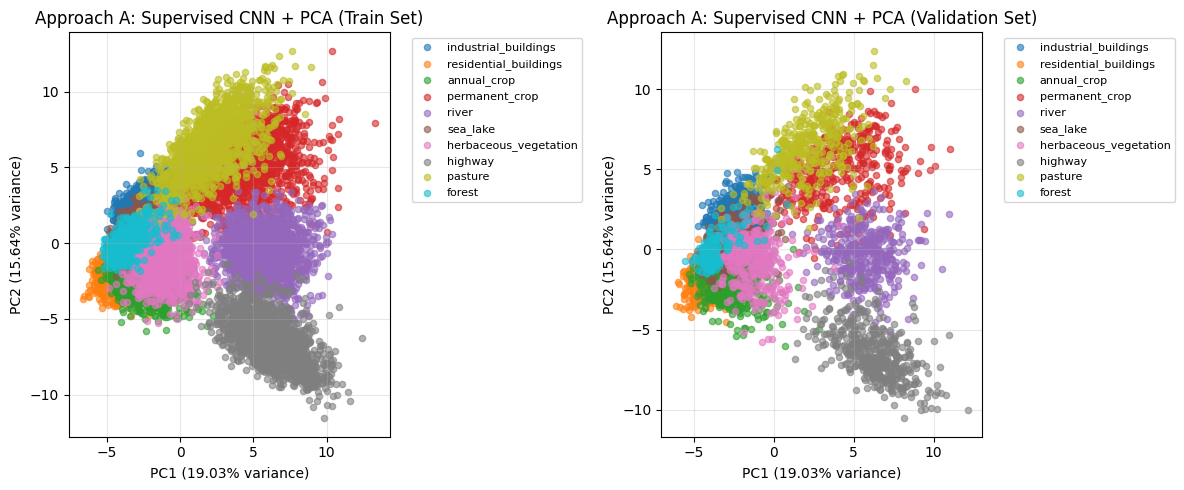


Approach B: Training Variational Autoencoder (VAE)...
Training VAE (this might take a while)...
Epoch 1/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 2634.6396 - val_loss: 2576.5876
Epoch 2/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 2571.1968 - val_loss: 2573.8494
Epoch 3/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 2568.7800 - val_loss: 2573.3174
Epoch 4/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 2566.7390 - val_loss: 2573.2197
Epoch 5/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 2565.8064 - val_loss: 2574.5325
Epoch 6/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 2569.4424 - val_loss: 2573.3923
Epoch 7/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 2564.3262 - val_loss: 2572.8013
Epoch 8/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 2564.2197 - val_loss: 2572.7273
Epoch 9/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 2564.4695 - val_loss: 2573.3960
Epoch 10/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 2567.0125 - v

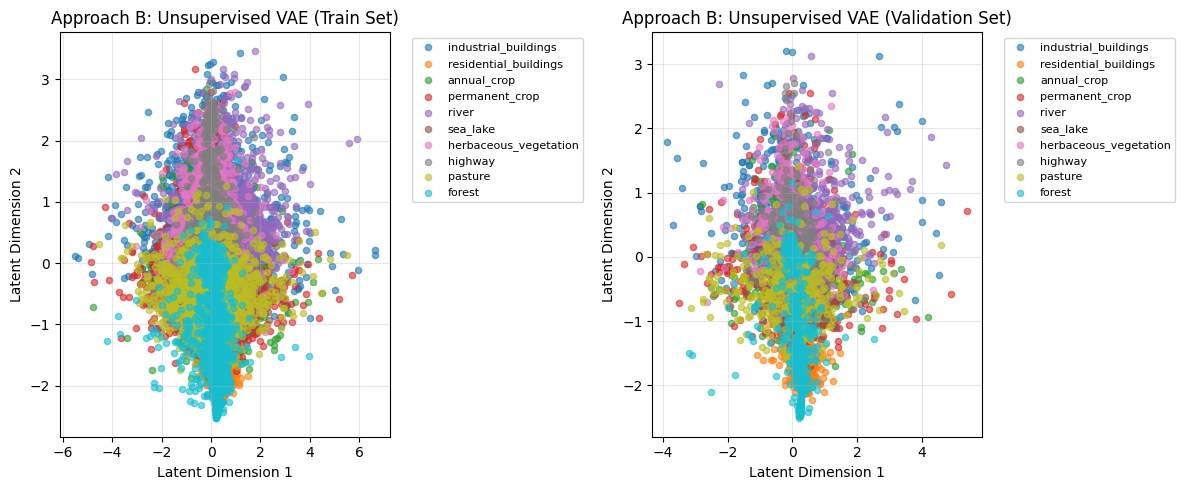


PLOTTING TRAINING HISTORY


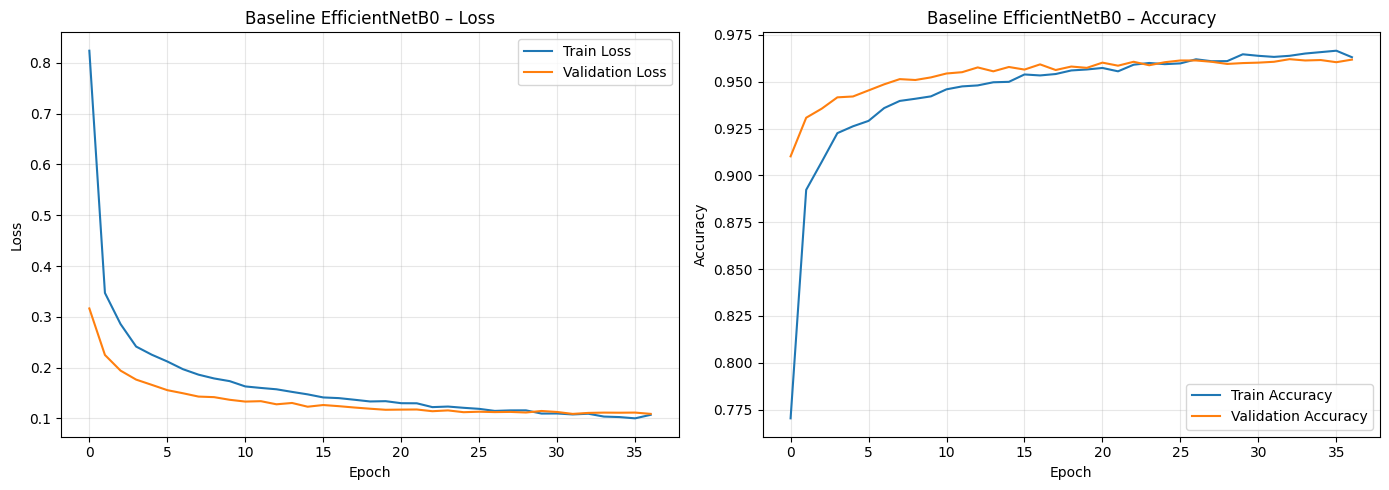

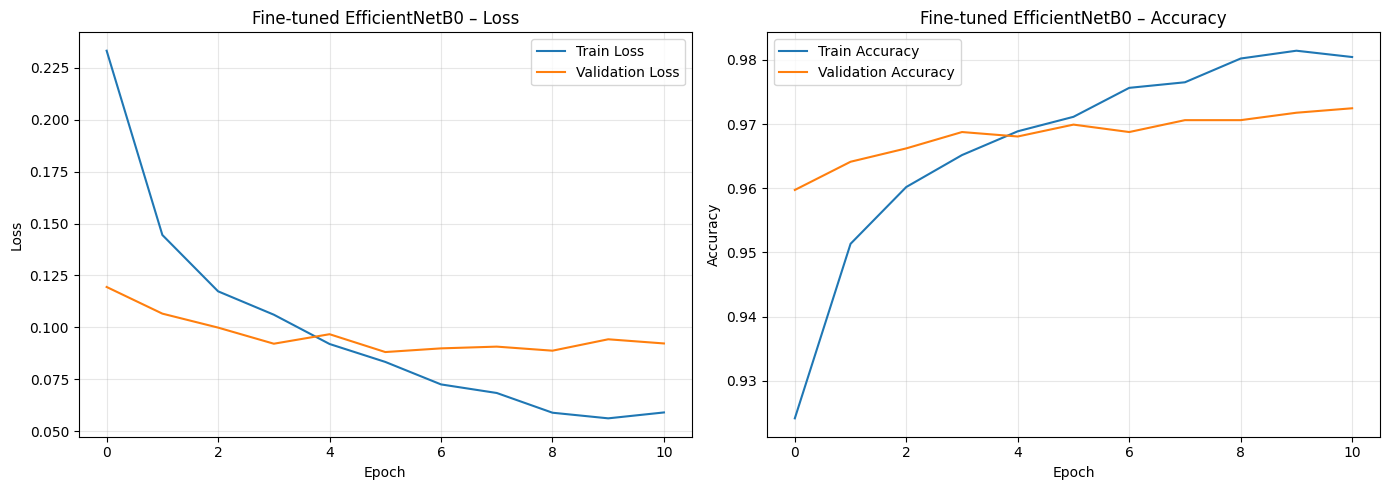

In [ ]:
# ===== PART 2.3: PCA vs VAE COMPARISON =====
print("\n" + "="*60)
print("LATENT SPACE INVESTIGATION: PCA vs VAE")
print("="*60)

# ===== APPROACH A: SUPERVISED PCA =====
# This approach uses features learned by the supervised CNN
# and reduces them to 2 dimensions using PCA for visualization
print("\nApproach A: Extracting features from CNN for PCA...")

# Create a feature extractor that outputs the 128-dimensional feature vector
# This layer contains learned representations before the final classification
feature_extractor = Model(
    inputs=model_baseline.input,
    outputs=model_baseline.get_layer("feature_vector").output
)

# Extract features from training and validation sets
features_train = feature_extractor.predict(X_train, verbose=0)
features_val = feature_extractor.predict(X_val, verbose=0)

print(f"Feature shape: {features_train.shape}")

# Apply PCA to reduce from 128 dimensions to 2 dimensions
pca = PCA(n_components=2)
features_2d_train = pca.fit_transform(features_train)
features_2d_val = pca.transform(features_val)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.4f}")

# Visualize PCA results - colored by class labels
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for i, class_name in enumerate(class_names):
    mask = y_train == i
    plt.scatter(features_2d_train[mask, 0], features_2d_train[mask, 1],
                label=class_name, alpha=0.6, s=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Approach A: Supervised CNN + PCA (Train Set)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for i, class_name in enumerate(class_names):
    mask = y_val == i
    plt.scatter(features_2d_val[mask, 0], features_2d_val[mask, 1],
                label=class_name, alpha=0.6, s=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Approach A: Supervised CNN + PCA (Validation Set)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== APPROACH B: UNSUPERVISED VAE =====
# This approach uses a Variational Autoencoder (VAE)
# VAE learns to compress images into a 2D latent space without using class labels
print("\nApproach B: Training Variational Autoencoder (VAE)...")

# Define the size of the latent space (2 dimensions for visualization)
latent_dim = 2

# ===== Build Encoder Network =====
# The encoder compresses 64x64x3 images into a 2D latent representation
encoder_inputs = tf.keras.Input(shape=(64, 64, 3))
x = tf.keras.layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = tf.keras.layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = tf.keras.layers.Conv2D(128, 3, activation="relu", strides=2, padding="same")(x)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)

# Output two vectors: mean and log variance of the latent distribution
z_mean = tf.keras.layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = tf.keras.layers.Dense(latent_dim, name="z_log_var")(x)

# Sampling layer: samples from the latent distribution
# This adds randomness which helps the VAE learn a smooth latent space
class Sampling(tf.keras.layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = Sampling()([z_mean, z_log_var])

# Create the encoder model
encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# ===== Build Decoder Network =====
# The decoder reconstructs the original image from the latent representation
latent_inputs = tf.keras.Input(shape=(latent_dim,))
x = tf.keras.layers.Dense(8 * 8 * 128, activation="relu")(latent_inputs)
x = tf.keras.layers.Reshape((8, 8, 128))(x)
x = tf.keras.layers.Conv2DTranspose(128, 3, activation="relu", strides=2, padding="same")(x)
x = tf.keras.layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = tf.keras.layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = tf.keras.layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)

# Create the decoder model
decoder = Model(latent_inputs, decoder_outputs, name="decoder")

# ===== Build Complete VAE Model (WORKING VERSION) =====

# Create a custom layer that computes and adds the VAE loss
class VAELossLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(VAELossLayer, self).__init__(**kwargs)

    def call(self, inputs):
        # inputs = [original_input, reconstruction, z_mean, z_log_var]
        original_input, reconstruction, z_mean, z_log_var = inputs

        # Reconstruction loss
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.keras.losses.binary_crossentropy(original_input, reconstruction),
                axis=(1, 2)
            )
        )

        # KL divergence loss
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1
            )
        )

        # Add the total loss
        total_loss = reconstruction_loss + kl_loss
        self.add_loss(total_loss)

        # Return the reconstruction (output of the model)
        return reconstruction

# Build the VAE model
vae_input = tf.keras.Input(shape=(64, 64, 3))
z_mean, z_log_var, z = encoder(vae_input)
reconstruction = decoder(z)

# Add the loss layer
vae_output = VAELossLayer()([vae_input, reconstruction, z_mean, z_log_var])

# Create the final model
vae = Model(vae_input, vae_output, name='vae')

# Normalize images to 0-1 range for VAE training
X_train_vae = X_train / 255.0
X_val_vae = X_val / 255.0

# Compile - no loss needed!
vae.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3)
)

# Train VAE
history_vae = vae.fit(
    X_train_vae,
    X_train_vae,
    epochs=30,
    batch_size=32,
    validation_data=(X_val_vae, X_val_vae),
    verbose=1
)
# Extract latent representations from trained encoder
z_mean_train, _, _ = encoder.predict(X_train_vae, verbose=0)
z_mean_val, _, _ = encoder.predict(X_val_vae, verbose=0)

# Visualize VAE latent space - colored by class labels
# Note: VAE was trained without seeing any labels!
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for i, class_name in enumerate(class_names):
    mask = y_train == i
    plt.scatter(z_mean_train[mask, 0], z_mean_train[mask, 1],
                label=class_name, alpha=0.6, s=20)
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('Approach B: Unsupervised VAE (Train Set)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for i, class_name in enumerate(class_names):
    mask = y_val == i
    plt.scatter(z_mean_val[mask, 0], z_mean_val[mask, 1],
                label=class_name, alpha=0.6, s=20)
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('Approach B: Unsupervised VAE (Validation Set)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Problem 1 Question 3

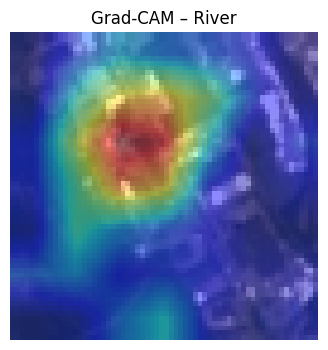

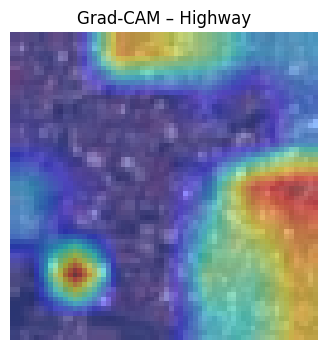

Sigma=0.0 | Accuracy=0.9672
Sigma=5.0 | Accuracy=0.7644
Sigma=10.0 | Accuracy=0.6052
Sigma=15.0 | Accuracy=0.4691
Sigma=20.0 | Accuracy=0.3857
Sigma=25.0 | Accuracy=0.3144
Sigma=30.0 | Accuracy=0.2700
Sigma=35.0 | Accuracy=0.2343
Sigma=40.0 | Accuracy=0.1991
Sigma=45.0 | Accuracy=0.1741
Sigma=50.0 | Accuracy=0.1470


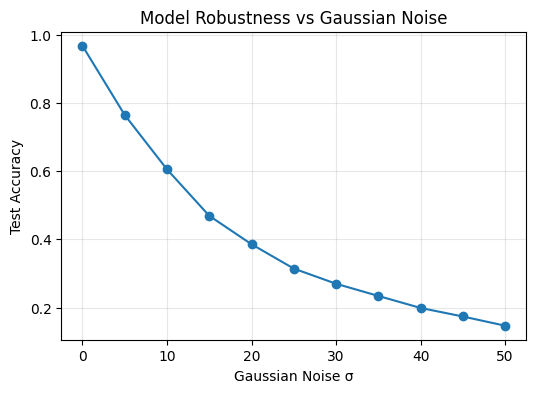

In [ ]:


# ------------------------------------------------
# Grad-CAM heatmap on image
# ------------------------------------------------

def plot_gradcam(image, heatmap, title):
    """
    Overlay a Grad-CAM heatmap on the original image.

    Parameters
    ----------
    image : np.ndarray
        Original image (64x64x3).
    heatmap : np.ndarray
        Grad-CAM heatmap (7x7).
    title : str
        Plot title.
    """

    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis], (64, 64)
    ).numpy().squeeze()

    plt.figure(figsize=(4, 4))
    plt.imshow(image.astype(np.uint8))
    plt.imshow(heatmap_resized, cmap="jet", alpha=0.45)
    plt.title(title)
    plt.axis("off")
    plt.show()


# ------------------------------------------------
# Grad-CAM implementation
# ------------------------------------------------

def compute_gradcam(model, image, class_index):
    """
    Simple and *correct* Grad-CAM implementation aligned with the exercises.

    Key idea:
    - Run ONE forward pass
    - Keep the feature maps that are actually used to compute the prediction
    - Backpropagate the class score to those feature maps

    This avoids the None-gradient problem caused by multiple disconnected
    forward passes.
    """

    backbone = model.get_layer("efficientnetb0")

    inputs = model.input

    # ----- Single forward pass (same graph) -----
    x = model.get_layer("resizing")(inputs)
    x = preprocess_input(x)
    x = model.get_layer("data_augmentation")(x)

    feature_maps = backbone(x, training=False)

    x = model.get_layer("global_average_pooling2d")(feature_maps)
    x = model.get_layer("feature_vector")(x)
    x = model.get_layer("dropout")(x)
    outputs = model.get_layer("dense")(x)

    grad_model = tf.keras.Model(
        inputs=inputs,
        outputs=[feature_maps, outputs]
    )

    image_tensor = tf.expand_dims(image, axis=0)

    with tf.GradientTape() as tape:
        conv_maps, predictions = grad_model(image_tensor)
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_maps)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_maps = conv_maps[0]
    heatmap = tf.reduce_sum(conv_maps * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()


# ------------------------------------------------
# Grad-CAM example: River vs Highway
# ------------------------------------------------

river_idx = class_names.index("river")
highway_idx = class_names.index("highway")

river_img = X_test[y_test == river_idx][0]
highway_img = X_test[y_test == highway_idx][0]

river_cam = compute_gradcam(model_baseline, river_img, river_idx)
highway_cam = compute_gradcam(model_baseline, highway_img, highway_idx)

plot_gradcam(river_img, river_cam, "Grad-CAM – River")
plot_gradcam(highway_img, highway_cam, "Grad-CAM – Highway")


# ------------------------------------------------
# Gaussian Noise Robustness Experiment
# ------------------------------------------------

def add_gaussian_noise(images, sigma):

    noise = np.random.normal(0, sigma, images.shape)
    noisy_images = images + noise
    return np.clip(noisy_images, 0, 255)


sigmas = np.linspace(0, 50, 11)
accuracies = []

for sigma in sigmas:
    X_test_noisy = add_gaussian_noise(X_test, sigma)
    loss, acc = model_baseline.evaluate(X_test_noisy, y_test, verbose=0)
    accuracies.append(acc)
    print(f"Sigma={sigma:.1f} | Accuracy={acc:.4f}")


plt.figure(figsize=(6, 4))
plt.plot(sigmas, accuracies, marker="o")
plt.xlabel("Gaussian Noise σ")
plt.ylabel("Test Accuracy")
plt.title("Model Robustness vs Gaussian Noise")
plt.grid(True, alpha=0.3)
plt.show()
